# PRACTICA 1 - CLASIFICACION DE JUGADORES

## 1. importaciones y Callbacks

In [1]:
# Tensorflow and tf.keras
import tensorflow as tf
from tensorflow import keras
print("Tensorflow version:",tf.__version__)
print("Keras version:",keras.__version__)

# Helper libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import my_callbacks
from tqdm import tqdm

Tensorflow version: 2.16.2
Keras version: 3.13.2


In [2]:
from keras.callbacks import EarlyStopping

# If the val_loss does not improve for 25 consecutive epochs, training will be stopped early.
# The goal is to save training time.
patienceStop_callback = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights= True)

## 2. carga de datos

In [3]:
ATT_FILE_NAME = "FootballPlayerPreparedCleanAttributes.csv"
ONE_HOT_ENCODED_CLASSES_FILE_NAME = "FootballPlayerOneHotEncodedClasses.csv"

df_atribs = pd.read_csv(ATT_FILE_NAME)
df_clases = pd.read_csv(ONE_HOT_ENCODED_CLASSES_FILE_NAME)

## 3. división en conjuntos

In [4]:
TRAIN_RATE=0.8

n_instancias = df_atribs.shape[0]
print(n_instancias)

n_train = int(n_instancias*TRAIN_RATE)
n_val =int((n_instancias - n_train)/2)
n_test = int(n_instancias - n_train - n_val)
print(n_train)
print(n_val)
print(n_test)

n_test + n_val + n_train == n_instancias

16134
12907
1613
1614


True

In [5]:
x_train = df_atribs.values[:n_train]
t_train = df_clases.values[:n_train]

x_val = df_atribs.values[n_train:n_train+n_val]
t_val = df_clases.values[n_train:n_train+n_val]

print ("x_train:",x_train.shape)
print ("t_train:",t_train.shape)

print ("x_dev:",x_val.shape)
print ("t_dev:",t_val.shape)

x_train: (12907, 22)
t_train: (12907, 4)
x_dev: (1613, 22)
t_dev: (1613, 4)


In [6]:
INPUTS = x_train.shape[1]
OUTPUTS = t_train.shape[1]
NUM_TRAINING_EXAMPLES = int(round(x_train.shape[0]/1))
NUM_DEV_EXAMPLES = int (round (x_val.shape[0]/1))

In [7]:
print(INPUTS)
print(OUTPUTS)

22
4


## 4. CONSTRUCCION DEL MODELO BASE

Modelo base sencillo: red neuronal shallow de una sola capa oculta (tanh + Softmax) sin optimización ni regulación. Comenzamos con 500 neuronas en la capa.

Hiperparámetros:

In [8]:
n_epochs = 1000
lr = 0.1
batch_size = 512
n_hidden = 500

### a) Crear el modelo

Creamos nuestro modelo inicial llamado "BaselineModel", a este le añadimos la capa de inputs y luego las dos restantes, la oculta tendra como funcion de activacion tanh por ser está computacionalmente barata y considerada apropiada para redes superficiales, y como función de activación de la capa de salida Softmax ya que nuestro problema se trata de una clasificación multiclase en One-Hot.

In [9]:
model = keras.Sequential(name="BaselineModel")
model.add(keras.layers.InputLayer(shape=(INPUTS,), batch_size=None))

model.add(keras.layers.Dense(n_hidden, activation="tanh"))

model.add(keras.layers.Dense(OUTPUTS, activation="softmax"))
model.summary()

Model: "BaselineModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │        11,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,504 (52.75 KB)

 Trainable params: 13,504 (52.75 KB)

 Non-trainable params: 0 (0.00 B)

Notamos que definimos la forma de la matriz de entrada como un vector columna con el mismo numero de elementos que numero de atributos por dato de entrada, y el numero de nueronas en la capa de salida coincide con el numero de clases ya que se trata de un problema de clasificacion.

Se tiene un total de 13,504 parámetros a ajustar, esto se aproxima al número de instancias por lo que se puede tener un caso con poco riesgo de overfitting.

### b) Compilar el modelo

Determinamos la función de pérdida que en este caso será crossentropy categórico para ajustarse a la naturaleza y el formato de los datos. Dado que es un primer modelo base, usaremos un optimizador de descenso de gradiente básico cuyo único parámetro es la tasa de aprendizaje.

Finalmente, nuestro analisis exploratorio y comparativo se basará en el accuracy como medida de rendimiento, por tanto lo incluimos como nuestra métrica.

In [10]:
model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
              metrics=["categorical_accuracy"])

### c) Entrenamiento del modelo en mini-lotes

Procedemos a entrenar el modelo con los datos de entrenamiento y sus clasificaciones esperadas, esto lo realizamos con el método por mini-lotes para tratar de evitar caer en minimos locales.

In [11]:
# Note that among all the callbacks constructed, we only use tqdm and patienceStop.
import time
tqdm_callback = my_callbacks.TqdmProgressCallback(epochs=n_epochs)
start = time.perf_counter()
history = model.fit(x_train, t_train, batch_size=batch_size, epochs=n_epochs, verbose=0, validation_data=(x_val, t_val), 
                    callbacks=[tqdm_callback,patienceStop_callback]) 
print (time.perf_counter() - start)

Epochs:  84%|████████▎ | 835/1000 [01:11<00:14, 11.70it/s]

71.41859050001949


Vemos que solo se llegan a realizar un 5% de las épocas asignadas (500), esto se debe al patienceStop_callback que detecta que la red no está "aprendiendo" durante un cierto número de épocas y por tanto no lo hará si sigue. El tiempo ha sido de 2.89199s y 8.77 iteeraciones por segundo.

### d) Vemos resultados

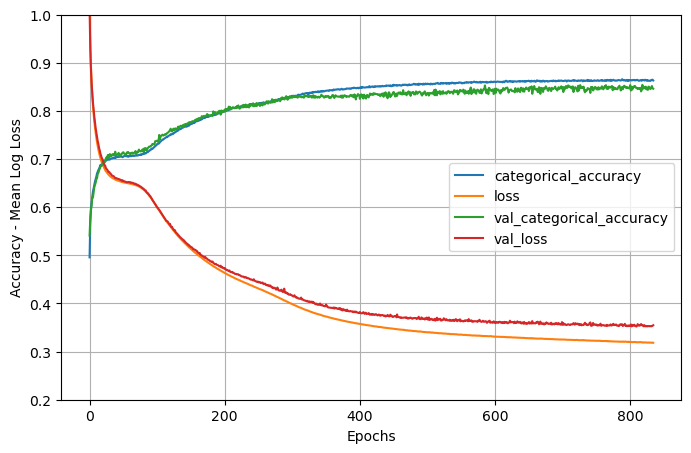

In [12]:
results=pd.DataFrame(history.history)
results.plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel ("Epochs")
plt.ylabel ("Accuracy - Mean Log Loss")
plt.gca().set_ylim(0.2, 1) # set the vertical range to [0.4,1]
plt.show()

De la gráfica podemos ver que los resultados son bastante mejorables, con las accuracies tanto del entrenamiento como de la validación rondando el 0.7. 

In [13]:
results[-1:]

,categorical_accuracy,loss,val_categorical_accuracy,val_loss
834,0.86333,0.318382,0.846249,0.354796


In [14]:
dev_predictions=model.predict(x_val).round(2)
dev_predictions[:20]

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step


array([[0.02, 0.81, 0.16, 0.  ],
       [0.  , 0.79, 0.21, 0.  ],
       [0.77, 0.23, 0.  , 0.  ],
       [0.  , 0.  , 0.27, 0.73],
       [0.08, 0.89, 0.03, 0.  ],
       [0.02, 0.94, 0.04, 0.  ],
       [0.  , 0.  , 0.82, 0.18],
       [1.  , 0.  , 0.  , 0.  ],
       [0.85, 0.15, 0.  , 0.  ],
       [0.  , 0.12, 0.87, 0.01],
       [0.  , 0.  , 0.  , 1.  ],
       [0.06, 0.92, 0.01, 0.  ],
       [0.62, 0.38, 0.  , 0.  ],
       [0.12, 0.86, 0.01, 0.  ],
       [0.04, 0.84, 0.12, 0.  ],
       [0.  , 0.01, 0.9 , 0.09],
       [0.  , 0.  , 0.08, 0.92],
       [0.  , 0.27, 0.73, 0.  ],
       [0.52, 0.47, 0.  , 0.  ],
       [0.  , 0.2 , 0.8 , 0.  ]], dtype=float32)

In [15]:
dev_rounded_predictions=np.round(dev_predictions)
indices = np.argmax(dev_predictions,1)
for row, index in zip(dev_rounded_predictions, indices): row[index]=1
dev_rounded_predictions[:20]

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.]], dtype=float32)

In [16]:
t_val[:20] #target classes

array([[0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]])

In [17]:
dev_correct_predictions = np.equal(np.argmax(dev_rounded_predictions,1),np.argmax(t_val,1))
print (dev_correct_predictions[:30])

[False  True False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False False False  True False  True  True
  True  True  True False  True  True]


In [18]:
from collections import Counter
Counter (dev_correct_predictions)

Counter({True: 1367, False: 246})

In [19]:
dev_sparse_predictions = np.argmax (dev_predictions,axis=1)
dev_sparse_targets = np.argmax(t_val, axis=1)
print('Confusion Matrix')
c_m=pd.DataFrame(confusion_matrix(dev_sparse_predictions,dev_sparse_targets),columns=['True_Poor', 'True_Intermediate', 'True_Good', 'True_Excellent'])
c_m.insert(0,'Classes',['Pred_Poor', 'Pred_Intermediate', 'Pred_Good', 'Pred_Excellent'])
c_m['Sum']=c_m.sum(axis=1, numeric_only=True)
c_m

Confusion Matrix


,Classes,True_Poor,True_Intermediate,True_Good,True_Excellent,Sum
0,Pred_Poor,366,30,0,0,396
1,Pred_Intermediate,46,297,64,0,407
2,Pred_Good,0,54,371,26,451
3,Pred_Excellent,0,0,26,333,359


In [20]:
print('Classification Report')
classes = ['Poor', 'Intermediate', 'Good', 'Excellent']
print(classification_report(dev_sparse_targets, dev_sparse_predictions, target_names=classes))

Classification Report
              precision    recall  f1-score   support

        Poor       0.92      0.89      0.91       412
Intermediate       0.73      0.78      0.75       381
        Good       0.82      0.80      0.81       461
   Excellent       0.93      0.93      0.93       359

    accuracy                           0.85      1613
   macro avg       0.85      0.85      0.85      1613
weighted avg       0.85      0.85      0.85      1613



Conclusión y siguientes pasos: se esta ante un claro caso de underfitting, es decir, hace falta más complejidad en la arquitectura del modelo. Para esto probaremos primero a aumentar el número de neuronas en nuestra capa manteniendo la arquitectura de una única capa oculta.

In [21]:
tf.keras.backend.clear_session()

## 4. CONSTRUCCION DEL SEGUNDO MODELO

Aumentamos el numero de neuronas en la capa oculta a 1000.

Hiperparámetros:

In [22]:
n_epochs2 = 1000
lr = 0.1
batch_size = 512
n_hidden2 = 1000

### a) Crear el modelo

Creamos nuestro modelo inicial llamado "BaselineModel", a este le añadimos la capa de inputs y luego las dos restantes, la oculta tendra como funcion de activacion tanh por ser está computacionalmente barata y considerada apropiada para redes superficiales, y como función de activación de la capa de salida Softmax ya que nuestro problema se trata de una clasificación multiclase en One-Hot.

In [23]:
model2 = keras.Sequential(name="Model2")
model2.add(keras.layers.InputLayer(shape=(INPUTS,), batch_size=None))

model2.add(keras.layers.Dense(n_hidden2, activation="tanh"))

model2.add(keras.layers.Dense(OUTPUTS, activation="softmax"))
model2.summary()

Model: "Model2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         4,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,004 (105.48 KB)

 Trainable params: 27,004 (105.48 KB)

 Non-trainable params: 0 (0.00 B)

Esta vez se tiene un total de 27,004 parámetros a ajustar, por lo tanto hemos duplicado la complejuidad aun manteniendola dentro de un rango aceptable para la magnitud de nuestros datos.

### b) Compilar el modelo

El resto del proceso será igual ya que lo único cambiado ha sido el tamaño de la capa oculta.

In [24]:
model2.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
              metrics=["categorical_accuracy"])

### c) Entrenamiento del modelo en mini-lotes

Procedemos a entrenar el modelo con los datos de entrenamiento y sus clasificaciones esperadas, esto lo realizamos con el método por mini-lotes para tratar de evitar caer en minimos locales.

In [25]:
from keras.callbacks import EarlyStopping

# If the val_loss does not improve for 25 consecutive epochs, training will be stopped early.
# The goal is to save training time.
patienceStop_callback = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights= True)

In [26]:
# Note that among all the callbacks constructed, we only use tqdm and patienceStop.
import time
tqdm_callback = my_callbacks.TqdmProgressCallback(epochs=n_epochs2)
start = time.perf_counter()
history2 = model2.fit(x_train, t_train, batch_size=batch_size, epochs=n_epochs2, verbose=0, validation_data=(x_val, t_val), 
                    callbacks=[tqdm_callback,patienceStop_callback]) 
print (time.perf_counter() - start)

Epochs:  73%|███████▎  | 726/1000 [01:14<00:28,  9.69it/s]

74.92885666596703


Vemos que solo se llegan a realizar un 5% de las épocas asignadas (500), esto se debe al patienceStop_callback que detecta que la red no está "aprendiendo" durante un cierto número de épocas y por tanto no lo hará si sigue. El tiempo ha sido de 2.89199s y 8.77 iteeraciones por segundo.

### d) Vemos resultados

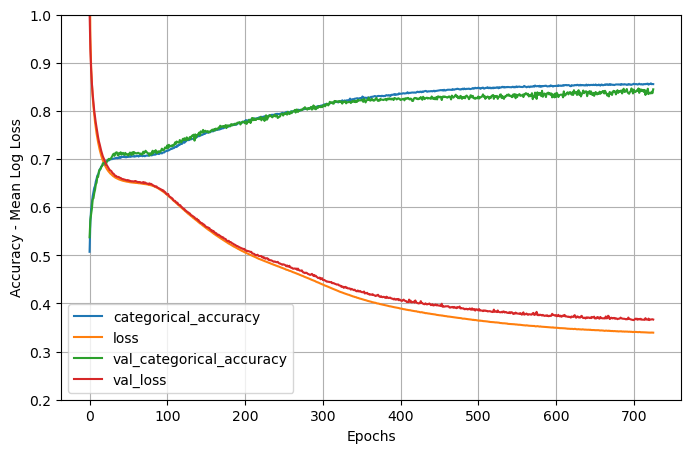

In [27]:
results2=pd.DataFrame(history2.history)
results2.plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel ("Epochs")
plt.ylabel ("Accuracy - Mean Log Loss")
plt.gca().set_ylim(0.2, 1) # set the vertical range to [0.4,1]
plt.show()

De la gráfica podemos ver que los resultados son bastante mejorables, con las accuracies tanto del entrenamiento como de la validación rondando el 0.7. 

In [28]:
results2[-1:]

,categorical_accuracy,loss,val_categorical_accuracy,val_loss
725,0.855815,0.339357,0.845009,0.366623


In [29]:
dev_predictions2=model2.predict(x_val).round(2)
dev_predictions2[:20]

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[0.03, 0.76, 0.22, 0.  ],
       [0.  , 0.66, 0.33, 0.  ],
       [0.81, 0.19, 0.  , 0.  ],
       [0.  , 0.  , 0.3 , 0.7 ],
       [0.09, 0.85, 0.06, 0.  ],
       [0.03, 0.9 , 0.07, 0.  ],
       [0.  , 0.  , 0.68, 0.32],
       [1.  , 0.  , 0.  , 0.  ],
       [0.79, 0.21, 0.  , 0.  ],
       [0.  , 0.15, 0.84, 0.01],
       [0.  , 0.  , 0.  , 1.  ],
       [0.07, 0.91, 0.02, 0.  ],
       [0.54, 0.46, 0.01, 0.  ],
       [0.21, 0.78, 0.01, 0.  ],
       [0.05, 0.79, 0.16, 0.  ],
       [0.  , 0.01, 0.8 , 0.19],
       [0.  , 0.  , 0.13, 0.87],
       [0.  , 0.23, 0.77, 0.  ],
       [0.51, 0.49, 0.  , 0.  ],
       [0.  , 0.22, 0.78, 0.  ]], dtype=float32)

In [30]:
dev_rounded_predictions2=np.round(dev_predictions2)
indices2 = np.argmax(dev_predictions2,1)
for row, index in zip(dev_rounded_predictions2, indices2): row[index]=1
dev_rounded_predictions2[:20]

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.]], dtype=float32)

In [31]:
t_val[:20] #target classes

array([[0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]])

In [32]:
dev_correct_predictions2 = np.equal(np.argmax(dev_rounded_predictions2,1),np.argmax(t_val,1))
print (dev_correct_predictions2[:30])

[False  True False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False False False  True False  True  True
  True  True False False  True  True]


In [33]:
from collections import Counter
Counter (dev_correct_predictions2)

Counter({True: 1364, False: 249})

In [34]:
dev_sparse_predictions2 = np.argmax (dev_predictions2,axis=1)
dev_sparse_targets = np.argmax(t_val, axis=1)
print('Confusion Matrix')
c_m2=pd.DataFrame(confusion_matrix(dev_sparse_predictions2,dev_sparse_targets),columns=['True_Poor', 'True_Intermediate', 'True_Good', 'True_Excellent'])
c_m2.insert(0,'Classes',['Pred_Poor', 'Pred_Intermediate', 'Pred_Good', 'Pred_Excellent'])
c_m2['Sum']=c_m2.sum(axis=1, numeric_only=True)
c_m2

Confusion Matrix


,Classes,True_Poor,True_Intermediate,True_Good,True_Excellent,Sum
0,Pred_Poor,361,29,0,0,390
1,Pred_Intermediate,51,292,58,0,401
2,Pred_Good,0,60,380,28,468
3,Pred_Excellent,0,0,23,331,354


In [35]:
print('Classification Report')
classes = ['Poor', 'Intermediate', 'Good', 'Excellent']
print(classification_report(dev_sparse_targets, dev_sparse_predictions2, target_names=classes))

Classification Report
              precision    recall  f1-score   support

        Poor       0.93      0.88      0.90       412
Intermediate       0.73      0.77      0.75       381
        Good       0.81      0.82      0.82       461
   Excellent       0.94      0.92      0.93       359

    accuracy                           0.85      1613
   macro avg       0.85      0.85      0.85      1613
weighted avg       0.85      0.85      0.85      1613



Conclusión: el accuracy se mantiene igual si no ligeramente peor, nuestro siguiente paso será probar con una red neuronal profunda de tres capas ya que esto tambien puede mejorar el problema de bias. 

In [36]:
tf.keras.backend.clear_session()

## 4. CONSTRUCCION DEL MODELO DNN

Además de incluir ahora tres capas ocultas, cambiaremos la función de activación de estas por ReLU ya que sabemos que tanh no funciona mejor en redes profundas. En cada capa se incluirán 1000 neuronas.
A mayores buscamos que esto mejore el tiempo de convergencia.

Hiperparámetros

In [ ]:
n_epochs3 = 1000
lr = 0.01
batch_size = 512
n_neurons_per_hlayer = [1000,1000, 1000]

### a) Crear el modelo

In [38]:
model3 = keras.Sequential(name="Feedforward_NN")
model3.add(keras.layers.InputLayer(shape=(INPUTS,), batch_size=None))

for neurons in n_neurons_per_hlayer:
  model3.add(keras.layers.Dense(neurons, activation="relu"))

model3.add(keras.layers.Dense(OUTPUTS, activation="softmax"))
model3.summary()

Model: "Feedforward_NN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         4,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,029,004 (7.74 MB)

 Trainable params: 2,029,004 (7.74 MB)

 Non-trainable params: 0 (0.00 B)

Ahora tenemos una complejidad de 2,029,004 parámetros a ajustar, lo cual implica un aumento muy significativo lo que podría resultar en una gran mejora de los resultados de rendimiento.

### b) Compilar el modelo

Dado que ahora solo queremos observar el efecto de la profundidad en el rendimiento, mantenemos el mismo optimizador de descenso de gradiente regular.

In [39]:
model3.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(learning_rate=lr),
              metrics=["categorical_accuracy"])

### c) Entrenamiento del modelo en mini-lotes

In [40]:
from keras.callbacks import EarlyStopping

# If the val_loss does not improve for 25 consecutive epochs, training will be stopped early.
# The goal is to save training time.
patienceStop_callback = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights= True)
# Note that among all the callbacks constructed, we only use tqdm and patienceStop.
import time
tqdm_callback = my_callbacks.TqdmProgressCallback(epochs=n_epochs3)
start = time.perf_counter()
history3 = model3.fit(x_train, t_train, batch_size=batch_size, epochs=n_epochs3, verbose=0, validation_data=(x_val, t_val), 
                    callbacks=[tqdm_callback,patienceStop_callback]) 
print (time.perf_counter() - start)

Epochs:   6%|▌         | 60/1000 [00:37<09:42,  1.61it/s]

37.18898458406329


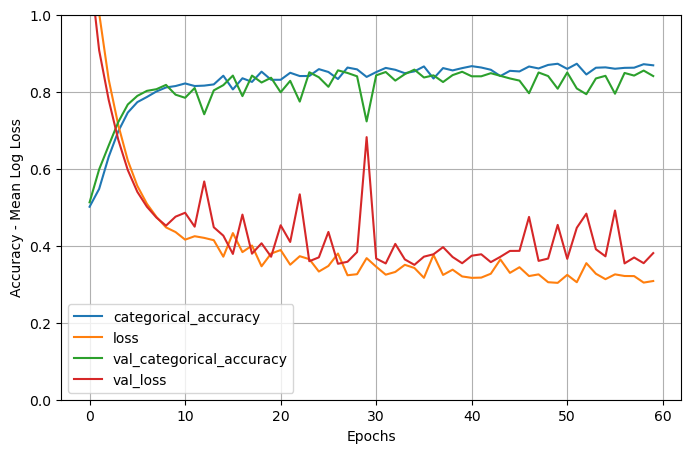

In [41]:
results3=pd.DataFrame(history3.history)
results3.plot(figsize=(8, 5))
plt.grid(True)
plt.xlabel ("Epochs")
plt.ylabel ("Accuracy - Mean Log Loss")
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

In [42]:
history3.params

{'verbose': 0, 'epochs': 1000, 'steps': 26}

In [43]:
results3[-1:]

,categorical_accuracy,loss,val_categorical_accuracy,val_loss
59,0.868598,0.308335,0.84067,0.380831


In [44]:
dev_predictions3=model3.predict(x_val).round(2)
dev_predictions3[:20]

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.02, 0.84, 0.14, 0.  ],
       [0.  , 0.88, 0.11, 0.  ],
       [0.82, 0.18, 0.  , 0.  ],
       [0.  , 0.  , 0.2 , 0.8 ],
       [0.18, 0.79, 0.02, 0.  ],
       [0.05, 0.88, 0.07, 0.  ],
       [0.  , 0.  , 0.63, 0.37],
       [1.  , 0.  , 0.  , 0.  ],
       [0.91, 0.08, 0.  , 0.  ],
       [0.  , 0.12, 0.88, 0.  ],
       [0.  , 0.  , 0.  , 1.  ],
       [0.09, 0.9 , 0.01, 0.  ],
       [0.7 , 0.29, 0.  , 0.  ],
       [0.17, 0.82, 0.02, 0.  ],
       [0.04, 0.83, 0.13, 0.  ],
       [0.  , 0.01, 0.89, 0.11],
       [0.  , 0.  , 0.04, 0.96],
       [0.  , 0.22, 0.78, 0.  ],
       [0.83, 0.17, 0.  , 0.  ],
       [0.  , 0.23, 0.77, 0.  ]], dtype=float32)

In [ ]:
dev_rounded_predictions3=np.round(dev_predictions3)
indices3 = np.argmax(dev_predictions3,1)
for row, index in zip(dev_rounded_predictions3, indices3): row[index]=1
dev_rounded_predictions3[:20]

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.]], dtype=float32)

In [46]:
t_val[:20] #target classes

array([[0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.]])

In [47]:
dev_correct_predictions3 = np.equal(np.argmax(dev_rounded_predictions3,1),np.argmax(t_val,1))
print (dev_correct_predictions3[:30])

[False  True False  True  True  True  True  True  True  True  True  True
  True  True  True  True  True False False False  True  True  True  True
  True  True  True False  True  True]


In [48]:
from collections import Counter
Counter (dev_correct_predictions3)

Counter({True: 1383, False: 230})

In [49]:
dev_sparse_predictions3 = np.argmax (dev_predictions3,axis=1)
dev_sparse_targets = np.argmax(t_val, axis=1)
print('Confusion Matrix')
c_m3=pd.DataFrame(confusion_matrix(dev_sparse_predictions3,dev_sparse_targets),columns=['True_Poor', 'True_Intermediate', 'True_Good', 'True_Excellent'])
c_m3.insert(0,'Classes',['Pred_Poor', 'Pred_Intermediate', 'Pred_Good', 'Pred_Excellent'])
c_m3['Sum']=c_m3.sum(axis=1, numeric_only=True)
c_m3

Confusion Matrix


,Classes,True_Poor,True_Intermediate,True_Good,True_Excellent,Sum
0,Pred_Poor,379,40,0,0,419
1,Pred_Intermediate,33,286,53,0,372
2,Pred_Good,0,55,378,19,452
3,Pred_Excellent,0,0,30,340,370


In [50]:
print('Classification Report')
classes = ['Poor', 'Intermediate', 'Good', 'Excellent']
print(classification_report(dev_sparse_targets, dev_sparse_predictions3, target_names=classes))

Classification Report
              precision    recall  f1-score   support

        Poor       0.90      0.92      0.91       412
Intermediate       0.77      0.75      0.76       381
        Good       0.84      0.82      0.83       461
   Excellent       0.92      0.95      0.93       359

    accuracy                           0.86      1613
   macro avg       0.86      0.86      0.86      1613
weighted avg       0.86      0.86      0.86      1613



Se ha probado este modelo con los valores de tasa de aprendizaje [0.1, 0.01, 0.001] obteniendo los mejores resultados para 0.01, esto se realizo ya que estabamos observando que con 0.1 el aprendizaje convergía extremadamente pronto por lo que posiblemente el salto era demasiado grande y no alcanzaba el verdadero mínimo óptimo, vimos que con 0.001 se llegaba a accuracies significativamente peores por lo que probablemente caía en un mínimo local. 

Los resultados de esta comparativa son los siguientes:

modelo_0.1	    

- 0,876	0,852

modelo_0.01	    

- 0,884	0,859

modelo_0.001

- 0,829	0,818

